# Image Normalization to Scale Pixel Values

In [3]:
import numpy as np
import cv2

# Function to normalize an image
def normalize_image(image):
    # Convert the image to float type for
    # avoiding overflow during operations
    img_float = image.astype(np.float32)
    # Find the minimum and maximum pixel values
    min_val = np.min(img_float)
    max_val = np.max(img_float)
    # Perform the normalization using
    # min−max scaling to [0, 255] range
    normalized_img = 255 * ((img_float-min_val)/\
        (max_val-min_val))
    # Convert back to an unsigned 8−bit type
    normalized_img = normalized_img.astype(np.uint8)
    return normalized_img
# Read an image(grayscale for simplicity)
image = cv2.imread('car_green_screen.jpg',
    cv2.IMREAD_GRAYSCALE)
# Normalize the image
normalized_image = normalize_image(image)
# Save the normalized image
cv2.imwrite('normalized_image.png',
    normalized_image)

True

# Handling Pixel Overflow in Image Processing

In [4]:
import numpy as np
import cv2
# Function to add a constant value to the
# image pixels and manage overflow
def add_constant_and_clip(image, constant_value):
    # Convert image to 16−bit to prevent
    # overflow during addition
    img_16bit = image.astype(np.uint16)
    # Add the constant value
    img_added = img_16bit + constant_value
    # Clip the values to the range [0, 255]
    # to prevent overflow
    img_clipped = np.clip(img_added, 0, 255)
    # Convert back to 8−bit image
    img_result = img_clipped.astype(np.uint8)
    return img_result
# Read an image(grayscale for simplicity)
image = cv2.imread('car_green_screen.jpg',
    cv2.IMREAD_GRAYSCALE)
# Constant value to add that could cause overflow
constant_value = 100
# Add constant value to the image and clip to manage overflow
result_image = add_constant_and_clip(image,
    constant_value)
# Save the result image
cv2.imwrite('result_image.png', result_image)

True

# Python Code for Image Masking Using the AND Operator

In [4]:
import cv2
import numpy as np

# Load the original image
image = cv2.imread('car_green_screen.jpg', 0)
# Create a binary mask for the region of interest (ROI)
# Assume the ROI is a square in the center of the image
height, width = image.shape
mask = np.zeros((height, width), dtype=np.uint8)
# Top−left corner of the ROI square
roi_corner = (width//4, height//4)
# Size of the ROI square
roi_size = (width//2, height//2)
cv2.rectangle(mask,
    roi_corner,
    (roi_corner[0] + roi_size[0],
    roi_corner[1] + roi_size[1]),
    255, -1)
# Apply the mask using the AND operator
masked_image = cv2.bitwise_and(image, image, mask = mask)
# Save the masked image
cv2.imwrite('masked_image.jpg', masked_image)

True

# Python Code for Applying a Kernel to an Image

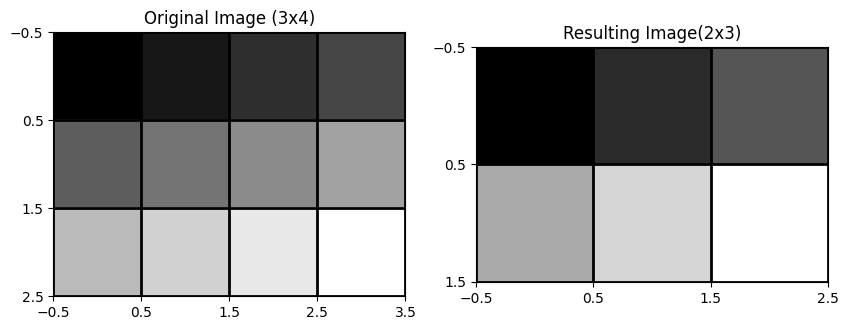

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Create a simple 3x4 image
# (array of pixel values)
original_image = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12]
    ])
# Define a 2x2 kernel
kernel = np.array([
    [0.25, 0.25],
    [0.25, 0.25]
    ])

# Function to apply the kernel to the image
def apply_kernel(image, kernel):
    kernel_height, kernel_width = kernel.shape
    image_height, image_width = image.shape
    # Resulting image will have reduced size
    result_height = image_height - kernel_height + 1
    result_width = image_width - kernel_width + 1
    result = np.zeros((result_height, result_width))
    # Apply the kernel to each position
    for i in range(result_height):
        for j in range(result_width):
            result[i, j] = np.sum(image[i:i + kernel_height,
                j : j+kernel_width] * kernel)
    return result
    
# Apply the kernel to the original image
resulting_image = apply_kernel(original_image,kernel)

# Display the original and resulting images
fig, axs = plt.subplots(1, 2, figsize =(10, 5))
axs[0].imshow(original_image, cmap='gray')
axs[0].set_title('Original Image (3x4)')
axs[0].set_xticks(np.arange (-0.5, 4, 1))
axs[0].set_yticks(np.arange (-0.5, 3, 1))
axs[0].grid(color='black',
    linestyle='-',
    linewidth=2)
axs[1].imshow(resulting_image, cmap='gray')
axs[1].set_title('Resulting Image(2x3)')
axs[1].set_xticks(np.arange(-0.5, 3, 1))
axs[1].set_yticks(np.arange(-0.5, 2, 1))
axs[1].grid(color='black',
    linestyle='-',
    linewidth=2)
plt.show()